--- Starting SVM (SVR) Consumption Forecasting ---
Optimization: Searching for best SVR parameters...
Best Parameters Found: {'C': 1, 'epsilon': 0.01, 'gamma': 'scale', 'kernel': 'rbf'}
Validation MAPE: 0.06%
Process complete. Figure saved at: E:\Projetos\ABMS-WP\figuras\figure-svm-forecast-validation.pdf


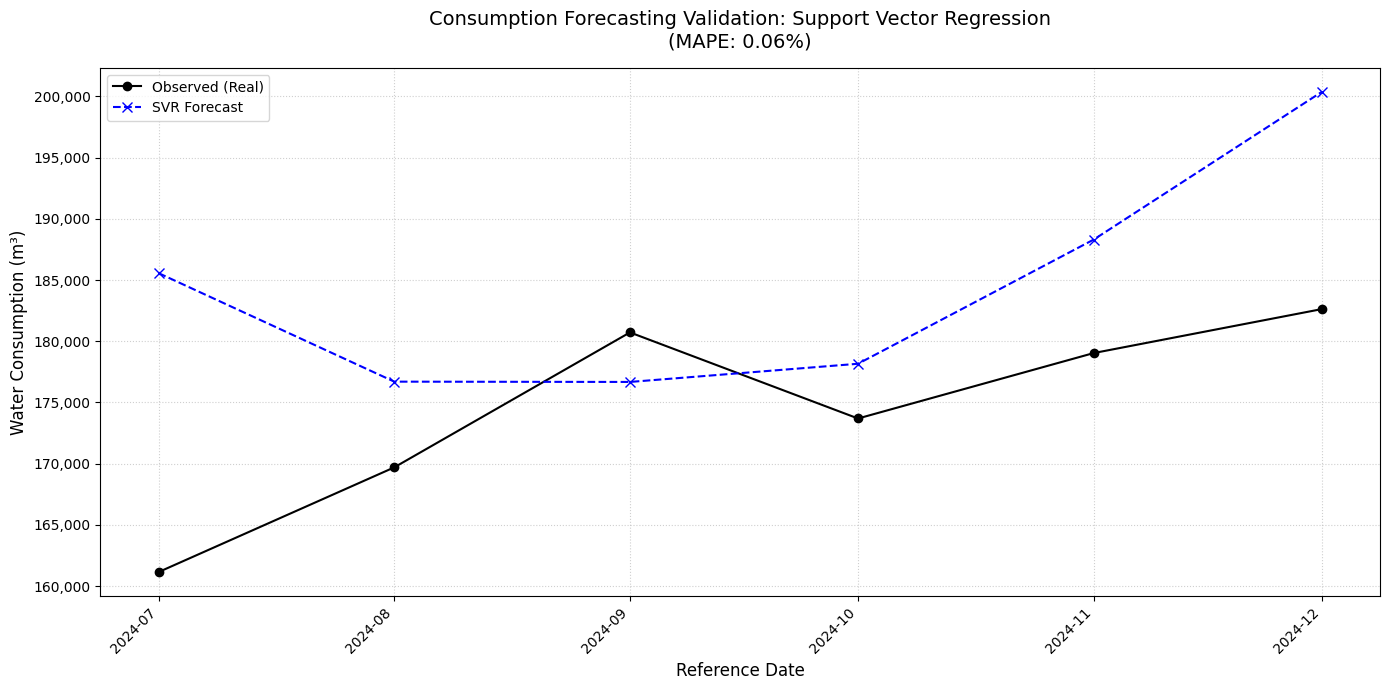

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import GridSearchCV

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = 'E:\\Projetos\\ABM-WP'
INPUT_FILE = os.path.join(BASE_PATH, 'includes', 'Tabela_consumo_Itapua_120m.csv')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')
OUTPUT_FIG = 'figure-svm-forecast-validation.pdf'

def create_dataset(data, look_back=1):
    #   Converts time series data into a supervised learning format.
    X, Y = [], []
    for i in range(len(data) - look_back):
        X.append(data[i:(i + look_back)])
        Y.append(data[i + look_back])
    return np.array(X), np.array(Y)

def main():
    print("--- Starting SVM Consumption Forecasting ---")

    # ==========================================
    # 2. Data Loading and Preprocessing
    # ==========================================
    if not os.path.exists(INPUT_FILE):
        print(f"Error: Input file not found at {INPUT_FILE}")
        return

    df = pd.read_csv(INPUT_FILE, sep=';')
    
    # Date formatting and aggregation
    df['AM_REFERENCIA'] = pd.to_datetime(df['AM_REFERENCIA'], format='%Y%m')
    df_aggregated = df.groupby('AM_REFERENCIA')['HCLQTCON'].sum().reset_index()
    df_aggregated = df_aggregated.sort_values(by='AM_REFERENCIA')
    
    # Normalization (0-1 range)
    scaler = MinMaxScaler(feature_range=(0, 1))
    df_aggregated['HCLQTCON_norm'] = scaler.fit_transform(df_aggregated[['HCLQTCON']])
    
    # Train-Test Split based on chronological periods
    # Training: Until end of 2023 | Testing: Year 2024
    train_mask = df_aggregated['AM_REFERENCIA'] <= pd.to_datetime('2023-12-31')
    test_mask = (df_aggregated['AM_REFERENCIA'] >= pd.to_datetime('2024-01-01')) & \
                (df_aggregated['AM_REFERENCIA'] <= pd.to_datetime('2024-12-31'))
    
    train_data = df_aggregated[train_mask]['HCLQTCON_norm'].values
    test_data = df_aggregated[test_mask]['HCLQTCON_norm'].values

    # Dataset windowing (sliding window)
    look_back = 6
    X_train, Y_train = create_dataset(train_data, look_back)
    X_test, Y_test = create_dataset(test_data, look_back)
    
    if len(X_train) == 0 or len(X_test) == 0:
        print("Error: Insufficient data for the selected look_back window.")
        return

    # ==========================================
    # 3. Hyperparameter Tuning (GridSearch)
    # ==========================================
    print("Optimization: Searching for best SVR parameters...")
    param_grid = {
        'kernel': ['rbf', 'linear'],
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto', 0.1],
        'epsilon': [0.01, 0.1]
    }
    
    svr = SVR()
    grid_search = GridSearchCV(svr, param_grid, cv=3, 
                               scoring='neg_mean_absolute_percentage_error', n_jobs=-1)
    grid_search.fit(X_train, Y_train)
    
    best_params = grid_search.best_params_
    print(f"Best Parameters Found: {best_params}")
    
    # Train final model with optimized parameters
    best_svr = SVR(**best_params)
    best_svr.fit(X_train, Y_train)
    
    # ==========================================
    # 4. Predictions and Evaluation
    # ==========================================
    predictions_norm = best_svr.predict(X_test)
    
    # Inverse scaling to return to original units (m³)
    predictions = scaler.inverse_transform(predictions_norm.reshape(-1, 1)).flatten()
    Y_test_inv = scaler.inverse_transform(Y_test.reshape(-1, 1)).flatten()
    
    # Retrieve dates for the test window
    test_dates = df_aggregated[test_mask]['AM_REFERENCIA'].iloc[look_back:].values
    
    # Calculate MAPE metric
    mape_value = mape(Y_test_inv, predictions)
    print(f"Validation MAPE: {mape_value:.2f}%")

    # ==========================================
    # 5. Visualization and Export
    # ==========================================
    fig, ax = plt.subplots(figsize=(14, 7))
    
    ax.plot(test_dates, Y_test_inv, label='Observed (Real)', color='black', 
            marker='o', linestyle='-', linewidth=1.5, markersize=6)
    ax.plot(test_dates, predictions, label='SVR Forecast', color='blue', 
            marker='x', linestyle='--', linewidth=1.5, markersize=7)

    # Formatting
    ax.set_title(f"Consumption Forecasting Validation: Support Vector Regression\n(MAPE: {mape_value:.2f}%)", 
                 fontsize=14, pad=15)
    ax.set_ylabel('Water Consumption (m³)', fontsize=12)
    ax.set_xlabel('Reference Date', fontsize=12)
    
    # Thousands separator for Y axis
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
    
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', frameon=True)
    plt.tight_layout()

    # Save to PDF for LaTeX integration
    if not os.path.exists(OUTPUT_DIR): os.makedirs(OUTPUT_DIR)
    save_path = os.path.join(OUTPUT_DIR, OUTPUT_FIG)
    plt.savefig(save_path, format='pdf', bbox_inches='tight')
    
    print(f"Process complete. Figure saved at: {save_path}")
    plt.show()

if __name__ == "__main__":
    main()